In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

In [2]:
db = duckdb.from_csv_auto('/Volumes/T7/IDX_data/CRMLSSold202506.csv').to_df()

In [3]:
db

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,None,False,<NA>,<NA>,False,5000.0,542181398,ops@downtowncondoguys.com,...,None,NaN,NaN,<NA>,1.0,None,92101,0.0,NaN,None
1,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,110000.0,540760713,nowjoanne@gmail.com,...,None,355936.0,NaN,False,NaN,None,93550,0.0,355936.0,None
2,SouthwestLosAngeles,SouthwestLosAngeles,None,True,<NA>,<NA>,<NA>,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,None,90008,NaN,20212.0,None
3,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,False,889000.0,523319952,hutton@cbappteam.com,...,None,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,None
4,SanDiego,SanDiego,Laminate,True,<NA>,<NA>,False,1700.0,518730969,mannybehar@yahoo.com,...,None,NaN,NaN,<NA>,0.0,None,92126,0.0,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22878,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,36900000.0,1019048995,btanger@intero.com,...,None,515314.8,NaN,<NA>,NaN,Other,95070,NaN,515314.8,None
22879,WestSanGabrielValley,WestSanGabrielValley,None,True,<NA>,<NA>,True,9180000.0,1018931071,sostlund@lee-assoc.com,...,None,174240.0,5.0,False,4.0,Capistrano Unified,92679,695.0,174240.0,None
22880,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,349000.0,1016273554,sara@coastalcahomes.com,...,None,138521.0,NaN,<NA>,NaN,Other,93907,214.0,138521.0,None
22881,OrangeCounty,OrangeCounty,"Stone,Wood",True,<NA>,<NA>,False,17000.0,1014281750,Leeann@canadaygroup.com,...,None,5950.0,1.0,False,2.0,Laguna Beach Unified,92651,0.0,5950.0,None


In [4]:
db.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,...,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,2.281100e+04,2.288300e+04,22883,2.288300e+04,22879.000000,22880.000000,21308.000000,2.284800e+04,22883.000000,2.288300e+04,...,22883,22443,22882,110.000000,18732.00000,2.106300e+04,12364.000000,19916.000000,15665.000000,2.104100e+04
mean,8.973742e+05,1.109938e+09,2025-06-15 05:17:54.981427,8.922487e+05,34.548733,-118.458038,1825.190867,8.619410e+05,41.476992,1.109938e+09,...,2025-06-15 05:17:54.981427,2025-05-19 17:36:26.178318,2025-04-01 02:50:59.103225,55.609091,1.37177,5.234909e+04,1.902378,1.778721,177.400540,4.638715e+05
min,0.000000e+00,4.218253e+08,2025-06-01 00:00:00,0.000000e+00,0.000000,-156.450320,0.000000,1.400000e+00,-26.000000,4.218253e+08,...,2025-06-01 00:00:00,2021-07-25 00:00:00,2015-05-15 00:00:00,0.000000,1.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,4.750000e+04,1.109110e+09,2025-06-09 00:00:00,4.000000e+04,33.733862,-118.561905,1184.000000,4.737500e+04,9.000000,1.109110e+09,...,2025-06-09 00:00:00,2025-05-09 00:00:00,2025-03-19 00:00:00,0.000000,1.00000,5.009500e+03,1.000000,1.000000,0.000000,5.227000e+03
50%,6.490000e+05,1.112153e+09,2025-06-16 00:00:00,6.315000e+05,34.041916,-118.055588,1595.000000,6.380000e+05,22.000000,1.112153e+09,...,2025-06-16 00:00:00,2025-05-22 00:00:00,2025-04-22 00:00:00,0.000000,1.00000,7.207000e+03,2.000000,2.000000,0.000000,7.405000e+03
75%,1.100000e+06,1.113861e+09,2025-06-23 00:00:00,1.100000e+06,34.393690,-117.330082,2185.250000,1.099000e+06,50.000000,1.113861e+09,...,2025-06-23 00:00:00,2025-06-04 00:00:00,2025-05-12 00:00:00,0.000000,2.00000,1.219700e+04,3.000000,2.000000,283.000000,1.361100e+04
max,2.395000e+08,1.118608e+09,2025-06-30 00:00:00,9.000000e+08,45.772309,121.116478,39111.000000,6.800000e+07,1265.000000,1.118608e+09,...,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2000.000000,2.00000,2.831400e+08,34.000000,500.000000,8063.000000,2.090880e+09
std,2.331296e+06,1.438173e+07,NaN,6.084893e+06,1.651760,3.917697,1164.276153,1.394472e+06,62.518260,1.438173e+07,...,NaN,NaN,NaN,252.155300,0.48329,2.020131e+06,1.435027,4.649280,340.986858,2.056782e+07


Key features:
- ListingKey is ID
- Target? OriginalListPrice or ListPrice or ClosePrice?

Issues:
- NaN values coded inconsistent
- Possible invalid values in ParkingTotal, DaysOnMarket
- ListPrice not available for 35 houses (drop or impute?)

Notes: PropertyType="Residential" and PropertySubType="SingleFamilyResidence"

In [5]:
db['PropertyType'].value_counts()

PropertyType
Residential            15329
ResidentialLease        5376
Land                     706
ManufacturedInPark       638
ResidentialIncome        571
CommercialSale           135
CommercialLease          112
BusinessOpportunity       16
Name: count, dtype: int64

# Data Ingestion

Confirmed alignment and uniqueness of key

# Missing values identification

## Populate DB with all training data

In [4]:
training_months = range(6, 13)
conn = None
conn = duckdb.connect('CRMLS.db')
path = '../IDX_data/'
files = [f for f in os.listdir(path) if not f.startswith('.')]

conn.query(
    f"""
    CREATE TABLE IF NOT EXISTS Property AS
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('../IDX_data/{files[0]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
)

for n in range(1, len(files)):
    conn.query(
        f"""
    INSERT INTO Property
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('../IDX_data/{files[n]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
    )


In [12]:
db = conn.table("Property")
(db
 .filter(
    """
        PropertyType = 'Residential'
        AND PropertySubType = 'SingleFamilyResidence'
        AND ClosePrice > 0
        AND LivingArea > 0
        AND Latitude IS NOT NULL
        AND Longitude IS NOT NULL
        AND Latitude BETWEEN 32 AND 43
        AND Longitude BETWEEN -125 AND -113
    """)
 .select()
 .aggregate("count(ListingId)")
 ).fetchdf()


,count(ListingId)
0,280934


In [13]:
conn.query(
    """
    SELECT count(ListingId) FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
    """
)

┌──────────────────┐
│ count(ListingId) │
│      int64       │
├──────────────────┤
│           280934 │
└──────────────────┘

In [15]:
def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

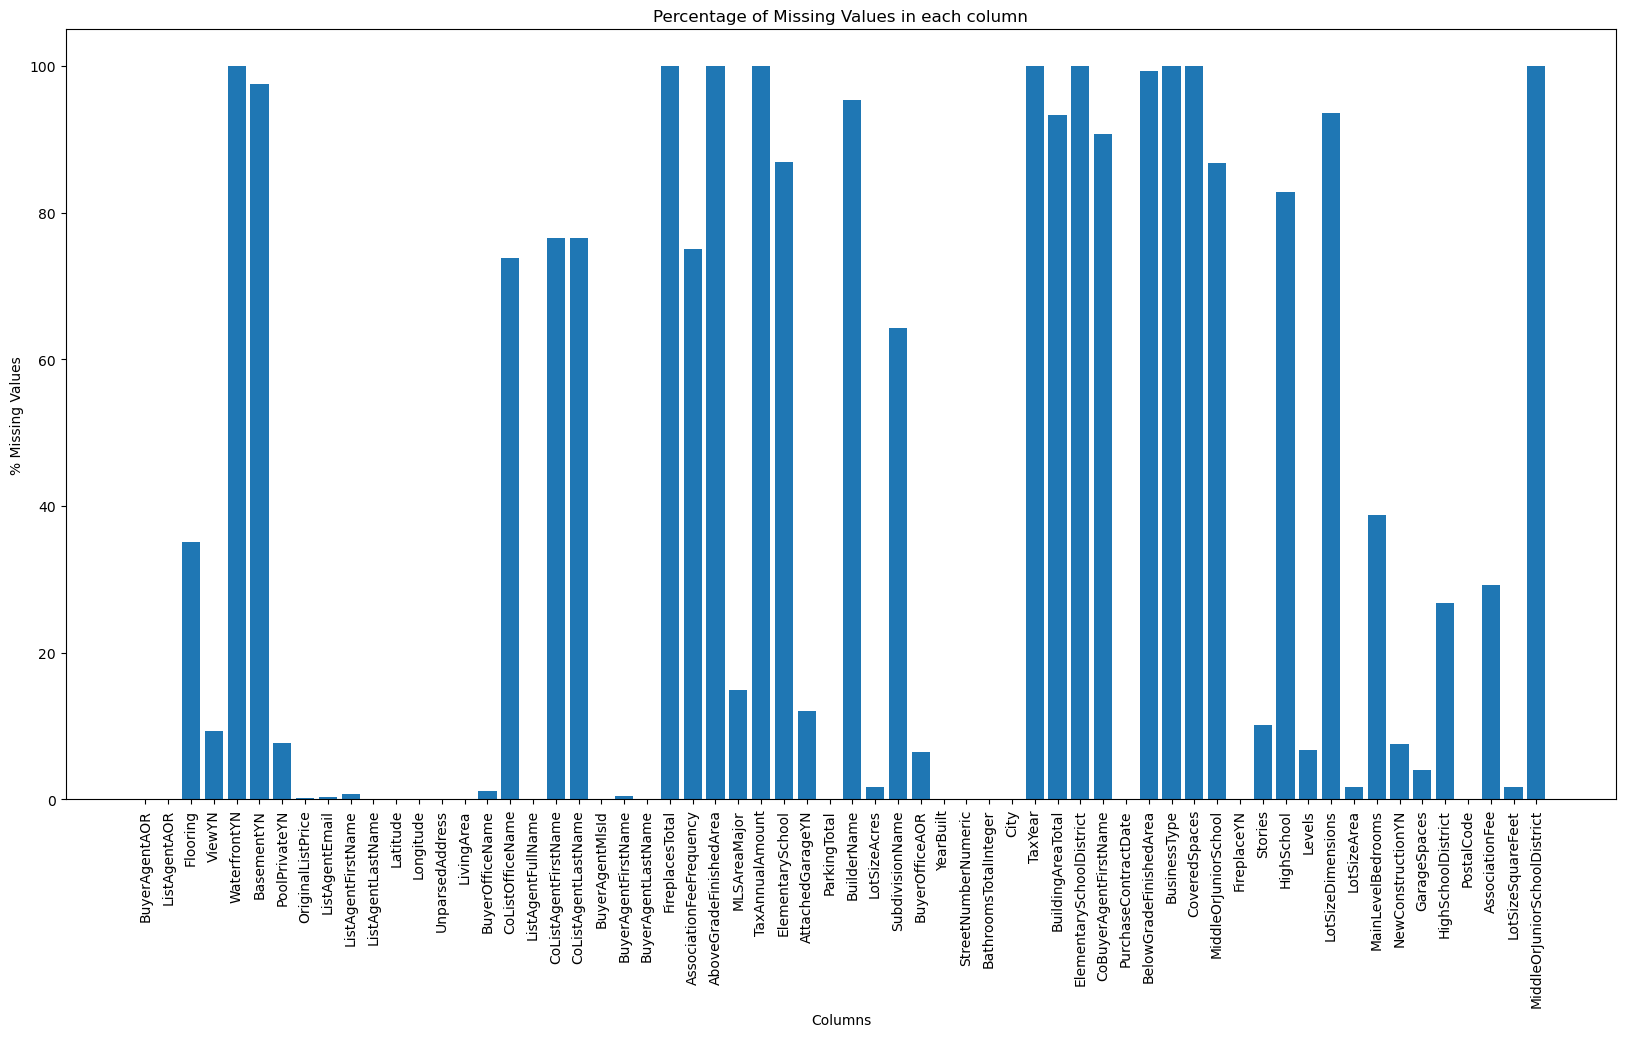

In [16]:
def reset_df():
    conn = duckdb.connect('CRMLS.db')
    df = conn.query(
        """
        SELECT *
        FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
        """
    ).to_df(date_as_object=False)
    df.set_index(['ListingId', 'ReadDate'], inplace=True)
    df.drop_duplicates(inplace=True)
    # df.set_index(['ListingId', 'ReadDate'], inplace=True)
    return df

df = reset_df()

column_na_plot(df)

For columns with > 50% NaNs, dropping the whole columns

In [6]:
na_columns = df.columns[df.isna().sum() > 0].tolist()
print(na_columns)

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'LivingArea', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'MLSAreaMajor', 'TaxAnnualAmount', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'FireplaceYN', 'Stories', 'HighSchool', 'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLev

## Check importance of remaining columns with NaNs

- Listing agent's name parts will be dropped and Id will be utilized to remove redundancy. However, need to compare predictive power to ListAgenAOR to see if it is needed to go in details.
- BuyerAgents information will be discarded as we can't judge people behavior based on their name.
- MainLevelBedroom is dropped due to redundancy and high missingness
- AssociationFees can be imputed with 0 to indicate the property doesn't have HOA fees.
- Drop ListingPrice and OriginalListingPrice per instructions from Aidan
- Drop ListingId fields to reduce overfit.
- Drop MLSStatus as it only contain Closed status
- Drop ListingContractDate and ContractChangeDate as the focus is in close price and DaysOnMarket already contain the necessary info.
- Drop all geographic features to remove redundancy to ZIP code


In [17]:
df = reset_df()
higher_than_50_na = [col for col in df.columns if (df[col].isna().sum() * 100 / df.shape[0]) > 50]
df.drop(columns=higher_than_50_na, axis=1, inplace=True)
df = df[((df['ClosePrice'] > 0) & (df['Longitude'].notnull()) & (df['Latitude'].notnull())) & (df['LivingArea'] > 0)]
for column in df.columns:
    if ("uyer" in column) or ("Name" in column):
        df.drop(column, axis=1, inplace=True)
df.drop(['MainLevelBedrooms', 'AssociationFee', 'ListPrice', 'OriginalListPrice', 'PropertyType', 'PropertySubType', 'ListingKey', 'ListingKeyNumeric', 'PurchaseContractDate', 'MlsStatus', 'UnparsedAddress', 'StreetNumberNumeric', 'City', 'StateOrProvince'], axis=1, inplace=True)
df.drop(['HighSchoolDistrict', 'MLSAreaMajor', 'Flooring', 'Stories', 'ListAgentEmail', 'ContractStatusChangeDate', 'ListingContractDate'], axis=1, inplace=True)
# df = df[df['ClosePrice'].between(df['ClosePrice'].quantile(0.5), df['ClosePrice'].quantile(0.95))]

df['log_price'] = np.log(df['ClosePrice'])

In [18]:
df.columns

Index(['ListAgentAOR', 'ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice',
       'Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket', 'CountyOrParish',
       'AttachedGarageYN', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Levels',
       'LotSizeArea', 'NewConstructionYN', 'GarageSpaces', 'PostalCode',
       'LotSizeSquareFeet', 'log_price'],
      dtype='object')

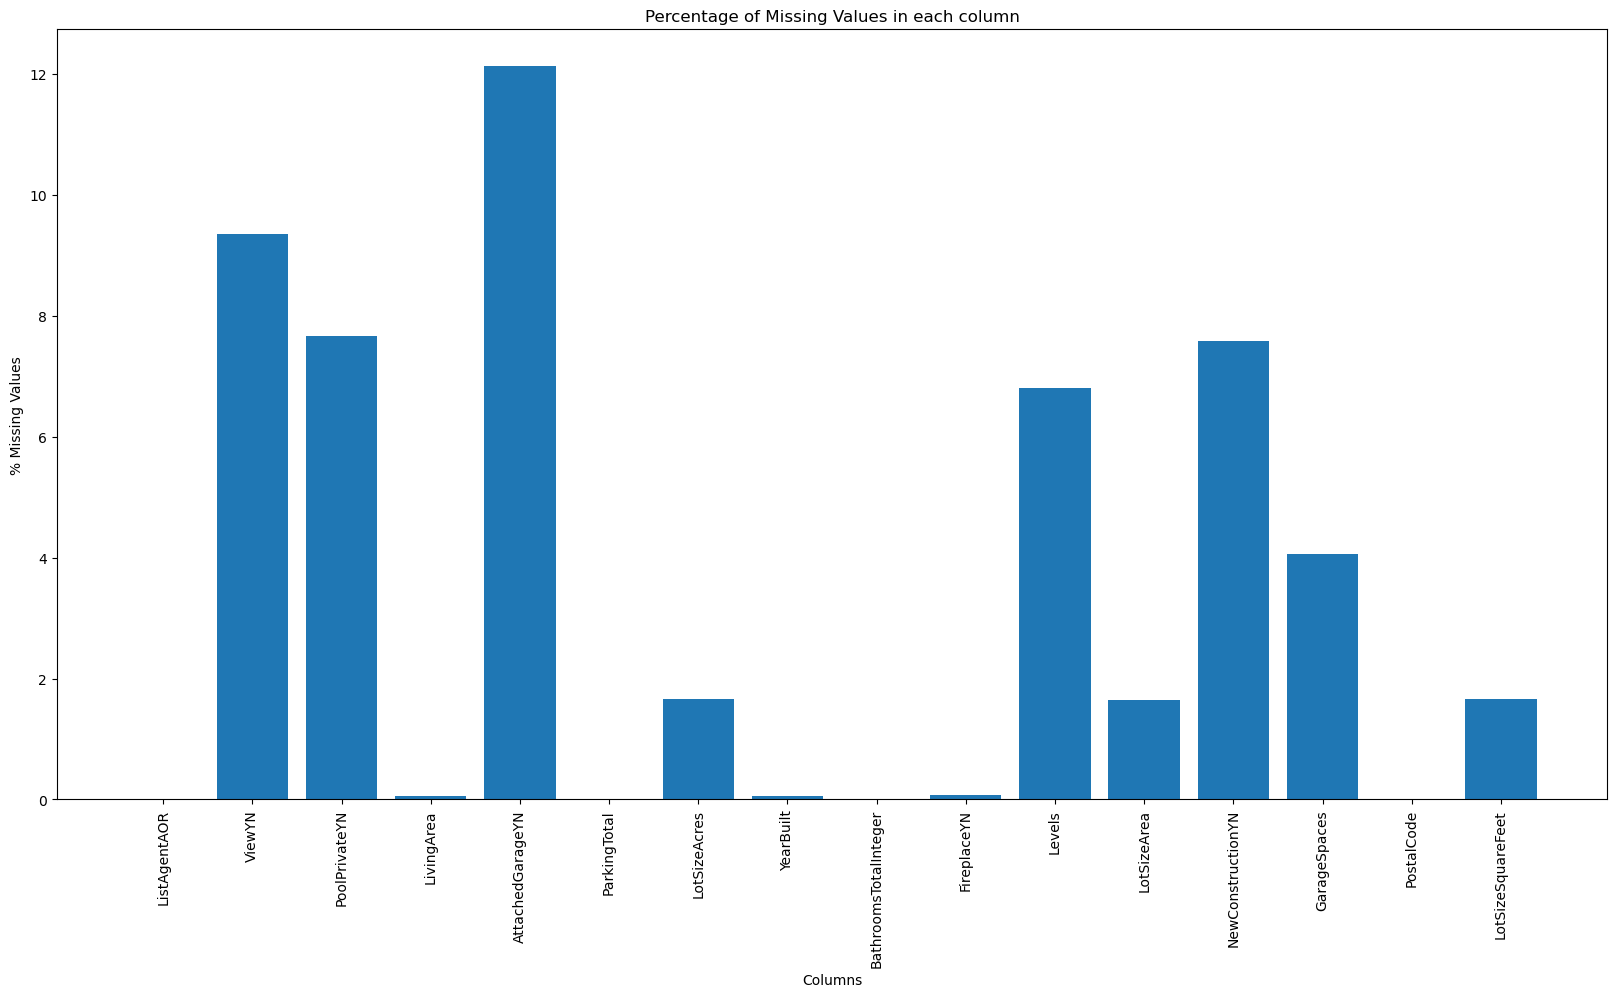

In [73]:
column_na_plot(df)

Questions:
- Is Listing agents info necessary?
- Does Zipcode alone sufficient to carry geographic info of the property or City + County + State (cannot encode quickly due to non-ordinal nature)?
- Is None in District mean property not in a school district? It has low availability, drop it?
- Should we use ContractListingDate as listing date? Is it necessary? (encode by cyclical feature)
- Should we use external inflation data?

Must imputation:
- LotSizeArea, LotSizeSquareFeet

Potential imputation:
- Levels / Stories

# Feature Engineer

In [52]:
def zipcode_parse(org: str):
    if org is not None:
        if len(org) >= 5:
            return org[:5]
        else:
            return 0
    else:
        return 0

df['PostalCode'] = df['PostalCode'].apply(zipcode_parse)

In [20]:
df.describe()

,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BedroomsTotal,LotSizeArea,GarageSpaces,LotSizeSquareFeet,log_price
count,78943,7.894300e+04,78937.000000,78937.000000,78900.000000,78943.000000,78942.000000,77636.000000,78897.000000,78932.000000,78943.000000,7.764400e+04,75744.000000,7.763400e+04,7.894300e+04
mean,2025-09-12 02:03:16.364465,1.330039e+06,34.745145,-118.615232,2042.034419,40.387571,2.915983,17.896793,1975.459472,2.622764,3.491203,1.700242e+04,2.005538,4.154659e+05,-inf
min,2025-06-01 00:00:00,0.000000e+00,0.000000,-124.193201,0.000000,-265.000000,-12.000000,0.000000,1776.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,-inf
25%,2025-07-22 00:00:00,6.250000e+05,33.768487,-119.164032,1384.000000,9.000000,2.000000,0.130000,1955.000000,2.000000,3.000000,5.429000e+03,2.000000,5.663000e+03,1.334551e+01
50%,2025-09-12 00:00:00,8.850000e+05,34.088241,-118.038944,1813.000000,22.000000,2.000000,0.167500,1976.000000,2.000000,3.000000,7.114500e+03,2.000000,7.295000e+03,1.369334e+01
75%,2025-11-03 00:00:00,1.400000e+06,34.852347,-117.267419,2429.000000,54.000000,3.000000,0.240000,1998.000000,3.000000,4.000000,1.000000e+04,2.000000,1.045400e+04,1.415198e+01
max,2025-12-31 00:00:00,9.895000e+08,43.784440,120.432670,56500.000000,894.000000,1111.000000,127631.000000,2026.000000,35.000000,19.000000,1.307236e+07,500.000000,1.938943e+09,2.071271e+01
std,NaN,8.428193e+06,1.727021,3.246931,1050.282115,50.249267,9.659813,944.281999,27.562474,1.126060,0.961613,1.059590e+05,3.312124,1.763652e+07,NaN


In [53]:
def cyclical_encoding(x):
    return np.sin(2 * np.pi * (x.month/12.0))

df['engineered_closed_date'] = df['CloseDate'].apply(cyclical_encoding)


# Imputation

Prepare imputation for base model

In [9]:
print(f'Mean: {df['ClosePrice'].mean()}')
print(f'Stdev: {df['ClosePrice'].std()}')

Mean: 1326501.7594527218
Stdev: 8430110.944962751


In [10]:
from scipy.stats import norm

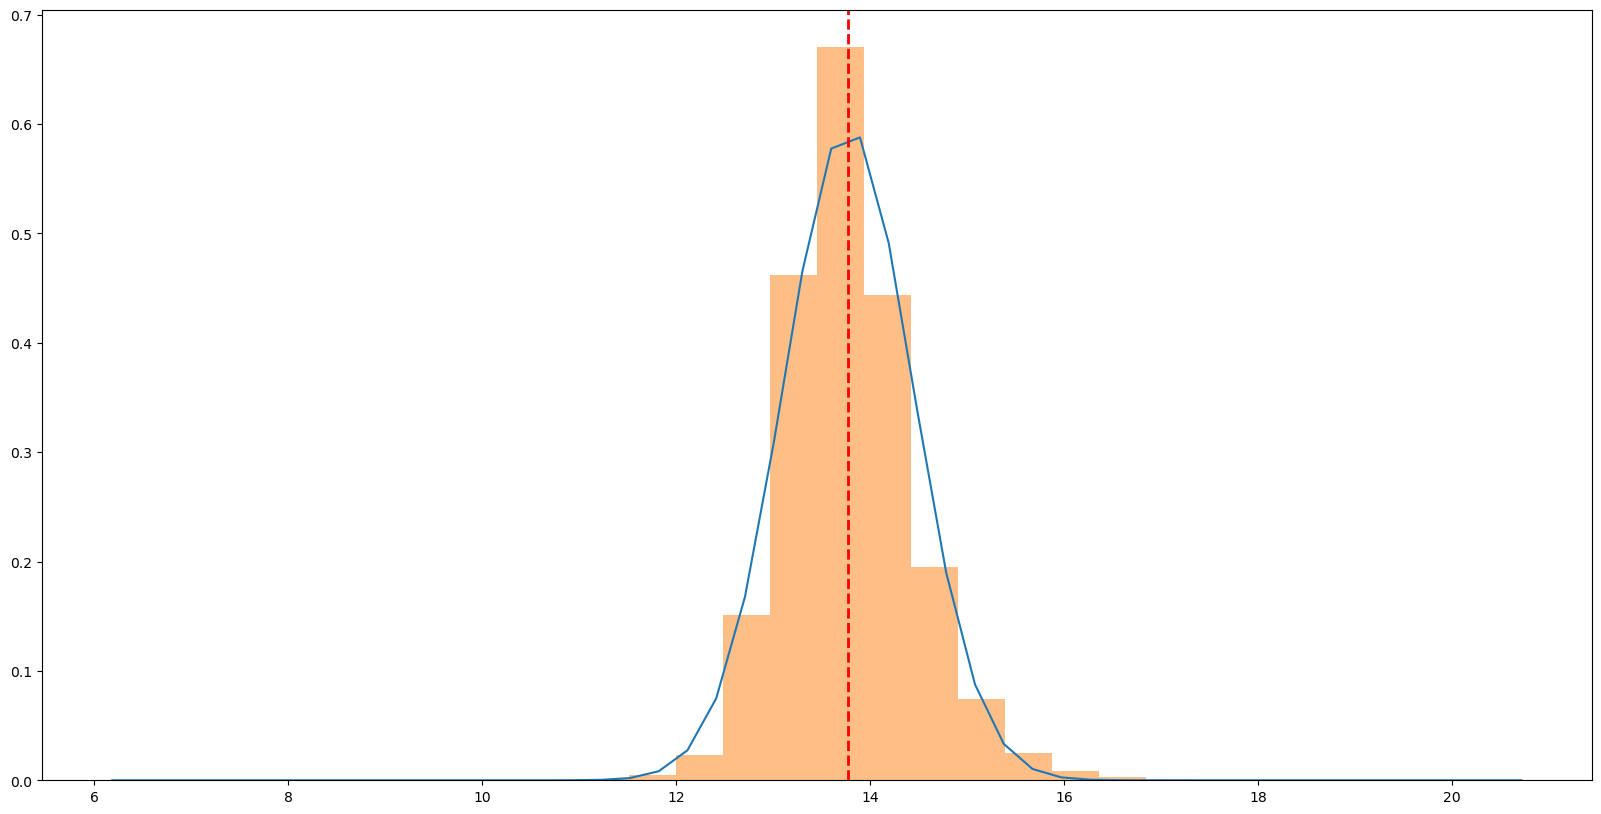

In [11]:
# Log price
# logged_price = np.log(df['ClosePrice'])
logged_price = df['log_price']

fig = plt.figure(figsize = (20,10))
domain = np.linspace(np.min(logged_price), np.max(logged_price))
mu, sigma = np.mean(logged_price), np.std(logged_price, ddof=1)
normal_curve = norm.pdf(domain, mu, sigma)
plt.plot(domain, normal_curve, label='Normal')
plt.hist(logged_price, bins=30, label='Normal', alpha=0.5, density=True)
plt.axvline(x=mu, color='r', linestyle='dashed', linewidth=2)


plt.show()

ClosePrice is Normal after logged

In [54]:
df_tmp = df.reset_index().reset_index()
# df_tmp['ListingId'].value_counts()
df_tmp.drop(columns=['ListingId'], axis=1, inplace=True)

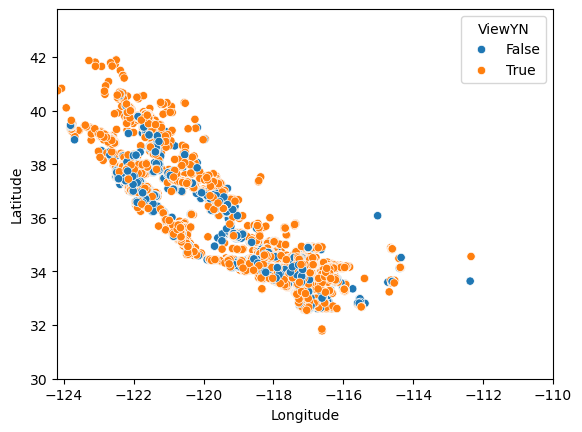

In [19]:
sns.scatterplot(
    data=df[df['ViewYN'].notnull()],
    x='Longitude',
    y='Latitude',
    hue='ViewYN',
)
plt.xlim(np.min(df['Longitude']), -110)
plt.ylim(30, np.max(df['Latitude']))

plt.show()

In [55]:
df

,,ListAgentAOR,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,CountyOrParish,...,BedroomsTotal,FireplaceYN,Levels,LotSizeArea,NewConstructionYN,GarageSpaces,PostalCode,LotSizeSquareFeet,log_price,engineered_closed_date
ListingId,ReadDate,,,,,,,,,,,,,,,,,,,,,
EV21134678,2025-06-01,TheInlandGateway,True,False,2025-06-13,890000.0,34.264692,-117.221040,3000.0,181,San Bernardino,...,3.0,True,Two,9600.0,True,2.0,92352,9600.0,13.698977,1.224647e-16
25559373,2025-06-01,BeverlyHillsGreaterLa,True,False,2025-06-30,1876384.0,34.107983,-118.390320,1800.0,87,Los Angeles,...,3.0,True,Two,10400.0,False,NaN,90046,10400.0,14.444857,1.224647e-16
ML82012939,2025-06-01,Mlslistings,False,<NA>,2025-06-30,4820000.0,37.567434,-122.388226,4270.0,0,San Mateo,...,6.0,True,None,22505.0,False,3.0,94010,22505.0,15.388284,1.224647e-16
PW25146750,2025-06-01,PacificWest,True,False,2025-06-30,865000.0,33.906058,-117.777782,1442.0,0,Orange,...,3.0,True,One,4800.0,False,2.0,92886,4800.0,13.670485,1.224647e-16
41103262,2025-06-01,BayEast,<NA>,False,2025-06-30,875000.0,37.705919,-122.059421,1086.0,0,Alameda,...,3.0,True,One,5500.0,False,4.0,94546,5500.0,13.681979,1.224647e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GD23212467,2025-12-01,Glendale,True,False,2025-12-05,640000.0,34.608952,-118.259648,2474.0,171,Los Angeles,...,3.0,True,One,105281.0,False,3.0,93551,105281.0,13.369223,-2.449294e-16
ML81923705,2025-12-01,Mlslistings,True,<NA>,2025-12-04,12000000.0,37.443497,-122.150296,5353.0,755,Santa Clara,...,5.0,True,None,15118.0,False,2.0,94301,15118.0,16.300417,-2.449294e-16
NS23056449,2025-12-01,NorthSanLuisObispo,True,False,2025-12-17,600000.0,35.903719,-120.982965,2038.0,894,Monterey,...,3.0,True,One,20.0,False,0.0,93426,871200.0,13.304685,-2.449294e-16


In [56]:
base_df = df_tmp[[column for column in df.columns if df[column].isna().sum() == 0]]
base_df

,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,CountyOrParish,BedroomsTotal,PostalCode,log_price,engineered_closed_date
0,2025-06-13,890000.0,34.264692,-117.221040,3000.0,181,San Bernardino,3.0,92352,13.698977,1.224647e-16
1,2025-06-30,1876384.0,34.107983,-118.390320,1800.0,87,Los Angeles,3.0,90046,14.444857,1.224647e-16
2,2025-06-30,4820000.0,37.567434,-122.388226,4270.0,0,San Mateo,6.0,94010,15.388284,1.224647e-16
3,2025-06-30,865000.0,33.906058,-117.777782,1442.0,0,Orange,3.0,92886,13.670485,1.224647e-16
4,2025-06-30,875000.0,37.705919,-122.059421,1086.0,0,Alameda,3.0,94546,13.681979,1.224647e-16
...,...,...,...,...,...,...,...,...,...,...,...
78858,2025-12-05,640000.0,34.608952,-118.259648,2474.0,171,Los Angeles,3.0,93551,13.369223,-2.449294e-16
78859,2025-12-04,12000000.0,37.443497,-122.150296,5353.0,755,Santa Clara,5.0,94301,16.300417,-2.449294e-16
78860,2025-12-17,600000.0,35.903719,-120.982965,2038.0,894,Monterey,3.0,93426,13.304685,-2.449294e-16
78861,2025-12-15,380000.0,34.261375,-117.211842,1452.0,38,San Bernardino,3.0,92352,12.847927,-2.449294e-16


In [44]:
# fig = plt.figure(figsize = (7,10))
# sns.barplot(data=base_df['CountyOrParish'].value_counts(), orient='h')
# # plt.xticks(rotation=90)
# plt.show()

In [32]:
# base_df = pd.get_dummies(base_df, columns=['CountyOrParish'], dtype=int)

In [57]:
y = base_df['log_price']
base_df.drop(columns=['log_price', 'ClosePrice', 'PostalCode', 'CountyOrParish', 'CloseDate'], axis=1, inplace=True)
base_df

/tmp/ipykernel_23792/1206377031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_df.drop(columns=['log_price', 'ClosePrice', 'PostalCode', 'CountyOrParish', 'CloseDate'], axis=1, inplace=True)


,Latitude,Longitude,LivingArea,DaysOnMarket,BedroomsTotal,engineered_closed_date
0,34.264692,-117.221040,3000.0,181,3.0,1.224647e-16
1,34.107983,-118.390320,1800.0,87,3.0,1.224647e-16
2,37.567434,-122.388226,4270.0,0,6.0,1.224647e-16
3,33.906058,-117.777782,1442.0,0,3.0,1.224647e-16
4,37.705919,-122.059421,1086.0,0,3.0,1.224647e-16
...,...,...,...,...,...,...
78858,34.608952,-118.259648,2474.0,171,3.0,-2.449294e-16
78859,37.443497,-122.150296,5353.0,755,5.0,-2.449294e-16
78860,35.903719,-120.982965,2038.0,894,3.0,-2.449294e-16
78861,34.261375,-117.211842,1452.0,38,3.0,-2.449294e-16


In [58]:
def trimming_quantiles(X, y, quantile=0.05):
        if not (0 <= quantile < 0.5):
            raise ValueError("quantile must be in [0, 0.5)")

        lo, hi = y.quantile([quantile, 1 - quantile])
        mask = (y >= lo) & (y <= hi)
        return X.loc[mask], y.loc[mask]

def train_test_split_with_trimming(df, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=test_size, random_state=random_state)
    X_train, y_train = trimming_quantiles(X_train, y_train)
    X_test, y_test = trimming_quantiles(X_test, y_test)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_with_trimming(base_df, y, test_size=0.2, random_state=42)


# Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.2416705280301764

In [60]:
y_predicted = model.predict(X_test)
error = np.pow((y_predicted - y_test), 2)


In [ ]:
# Johnny code




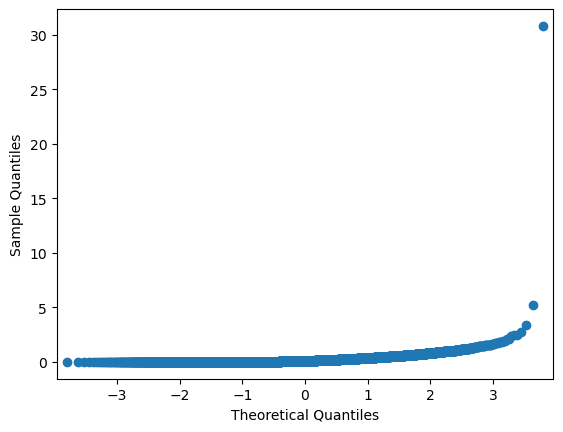

In [61]:
from statsmodels.graphics.gofplots import qqplot

qqplot(error, ax=plt.gca())
plt.show()

## Conclusion

- Error not normally distributed. Cannot proceed with Linear Regression
-

# XGBoost (Eddie part)

To avoid normal error assumption, I used Smearing factor from: https://people.stat.sc.edu/hoyen/PastTeaching/STAT704-2022/Notes/Smearing.pdf when transforming logged price back to its original scale

In [62]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
model.score(X_test, y_test)

0.8873711456224866

In [67]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

In [63]:
scores = np.exp(y_predicted - y_test)
smearing = np.mean(scores)
original_scaled_y_hat = smearing * np.exp(y_predicted)

In [64]:
original_scaled_y = np.exp(y_test)
error = original_scaled_y_hat - original_scaled_y

In [65]:
mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))   # RMSE = sqrt(MSE)
mse = np.mean(error**2)


In [66]:
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, MSE: {mse:.2f}')

MAE: 133592.24, RMSE: 213374.07, MSE: 45528493620.91


By using non-NA features and encoded county information, I achieved a model that can predict with R2 = 0.887 and average RMSE of 213,374$

<Axes: xlabel='log_price', ylabel='Count'>

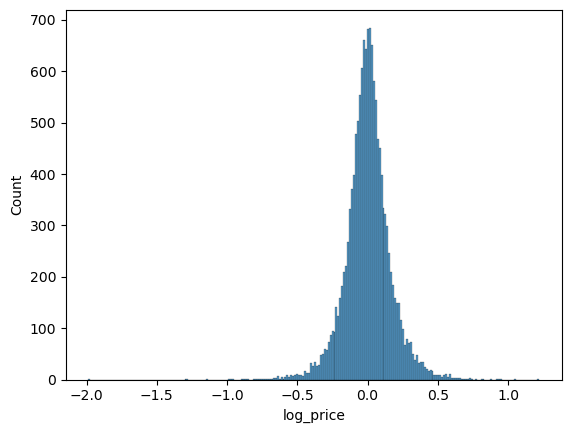

In [73]:
residuals = y_predicted - y_test
abs_residuals = np.abs(residuals)
mdape = np.mean(abs_residuals / (y_test * 100))
sns.histplot(data=residuals)


<Axes: xlabel='log_price', ylabel='log_price'>

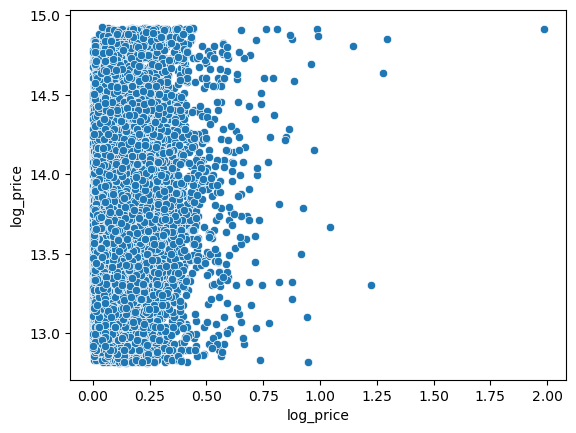

In [72]:
sns.scatterplot(x=abs_residuals, y=y_test)

In [75]:
print(mdape)

8.472164047975887e-05


# Close Price Engineering (Jenny part)
abvs


In [1]:
from src.Preprocessing import get_unprocessed_data
from src.Ingestion import DataIngestion

In [2]:
accessor = DataIngestion(data_path='../IDX_data')
df = get_unprocessed_data(accessor)

In [4]:
df.shape

(225096, 45)

In [30]:
accessor.query("""SELECT * FROM Property LIMIT 10""")

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,ReadDate
0,TriCounties,TriCounties,None,True,<NA>,<NA>,<NA>,20000.0,519281718,myagentjosephine@gmail.com,...,2.50,NaN,False,NaN,None,93560,0.0,108900.0,None,2025-09-01
1,HighDesert,HighDesert,None,True,<NA>,<NA>,<NA>,120000.0,508553099,lrethier@aol.com,...,653400.00,NaN,False,NaN,None,92344,NaN,653400.0,None,2025-09-01
2,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,299900.0,448373180,ocrealtorsteph@gmail.com,...,20.00,NaN,False,NaN,None,92595,0.0,871200.0,None,2025-09-01
3,SanDiego,SanDiego,None,True,<NA>,<NA>,False,3775000.0,1137354161,Sanjay.Solomon@compass.com,...,NaN,NaN,False,3.0,None,92037,NaN,NaN,None,2025-09-01
4,NorthSanDiegoCounty,NorthSanDiegoCounty,None,False,<NA>,<NA>,False,185000.0,1137353088,sharonjenkins4realestate@gmail.com,...,0.67,1.0,<NA>,0.0,San Marcos Unified,92078,2554.0,29185.2,None,2025-09-01
5,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,True,822000.0,1137349439,annb@loislauer.com,...,14560.00,5.0,False,2.0,Redlands Unified,92373,0.0,14560.0,None,2025-09-01
6,OrangeCounty,OrangeCounty,"Carpet,Vinyl,Wood",True,<NA>,<NA>,False,1575000.0,1137346577,Judy@JudyMcCartyRealty.com,...,3300.00,0.0,False,2.0,Saddleback Valley Unified,92630,255.0,3300.0,None,2025-09-01
7,SouthBay,SouthBay,None,True,<NA>,<NA>,False,3350000.0,1137309626,colin@colinaita.com,...,NaN,3.0,True,2.0,Hermosa,90254,0.0,NaN,None,2025-09-01
8,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Stone,Tile,Wood",True,<NA>,<NA>,<NA>,8022333.0,1137284778,bba@theagencyre.com,...,26981.00,NaN,False,NaN,None,90402,NaN,26981.0,None,2025-09-01
9,OrangeCounty,OrangeCounty,None,False,<NA>,<NA>,False,1525000.0,1137269984,ks@kasere.com,...,3749.00,0.0,True,2.0,Huntington Beach Union High,92708,212.0,3749.0,None,2025-09-01


In [1]:
from src.Preprocessing import get_preprocessed_data

df = get_preprocessed_data()
df.head()

,City,CountyOrParish,HighSchoolDistrict,Latitude,Longitude,MLSAreaMajor,PostalCode,StateOrProvince,StreetNumberNumeric,UnparsedAddress,...,ViewYN,YearBuilt,LotSizeAcres,LotSizeArea,LotSizeSquareFeet,AssociationFee,ClosePrice,DaysOnMarket,engineered_closed_date,log_price
0,La Jolla,San Diego,None,32.853478,-117.246741,92037 - La Jolla,92037,CA,8129.0,8129 Prestwick Dr,...,True,1969.0,0.1676,7128.0,7300.0,NaN,3775000.0,0,-1.0,15.143911
1,Redlands,San Bernardino,Redlands Unified,34.031403,-117.146152,268 - Redlands,92373,CA,1610.0,1610 Marjorie Street,...,True,1968.0,0.3343,14560.0,14560.0,0.0,822000.0,0,-1.0,13.619496
2,Lake Forest,Orange,Saddleback Valley Unified,33.646810,-117.703588,LS - Lake Forest South,92630,CA,21746.0,21746 Tahoe Ln,...,True,1976.0,0.0758,3300.0,3300.0,255.0,1575000.0,0,-1.0,14.269766
3,Los Angeles,Los Angeles,None,34.039218,-118.512774,C15 - Pacific Palisades,90402,CA,37.0,37 Haldeman Road,...,True,1925.0,0.6194,26981.0,26981.0,NaN,8022333.0,0,-1.0,15.897740
4,Fountain Valley,Orange,Huntington Beach Union High,33.700825,-117.979108,16 - Fountain Valley / Northeast HB,92708,CA,18009.0,18009 Hazel Court,...,False,2025.0,0.0861,3749.0,3749.0,212.0,1525000.0,0,-1.0,14.237505


In [2]:
df

,City,CountyOrParish,HighSchoolDistrict,Latitude,Longitude,MLSAreaMajor,PostalCode,StateOrProvince,StreetNumberNumeric,UnparsedAddress,...,ViewYN,YearBuilt,LotSizeAcres,LotSizeArea,LotSizeSquareFeet,AssociationFee,ClosePrice,DaysOnMarket,engineered_closed_date,log_price
0,La Jolla,San Diego,None,32.853478,-117.246741,92037 - La Jolla,92037,CA,8129.0,8129 Prestwick Dr,...,True,1969.0,0.1676,7128.00,7300.0,NaN,3775000.0,0,-1.0,15.143911
1,Redlands,San Bernardino,Redlands Unified,34.031403,-117.146152,268 - Redlands,92373,CA,1610.0,1610 Marjorie Street,...,True,1968.0,0.3343,14560.00,14560.0,0.0,822000.0,0,-1.0,13.619496
2,Lake Forest,Orange,Saddleback Valley Unified,33.646810,-117.703588,LS - Lake Forest South,92630,CA,21746.0,21746 Tahoe Ln,...,True,1976.0,0.0758,3300.00,3300.0,255.0,1575000.0,0,-1.0,14.269766
3,Los Angeles,Los Angeles,None,34.039218,-118.512774,C15 - Pacific Palisades,90402,CA,37.0,37 Haldeman Road,...,True,1925.0,0.6194,26981.00,26981.0,NaN,8022333.0,0,-1.0,15.897740
4,Fountain Valley,Orange,Huntington Beach Union High,33.700825,-117.979108,16 - Fountain Valley / Northeast HB,92708,CA,18009.0,18009 Hazel Court,...,False,2025.0,0.0861,3749.00,3749.0,212.0,1525000.0,0,-1.0,14.237505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494715,Thermal,Riverside,None,33.602236,-116.147017,316 - Thermal,92274,CA,61680.0,61680 Fullerton Dr,...,True,2019.0,0.3200,13939.00,13939.0,2400.0,2625000.0,560,-0.5,14.780591
494716,Yucca Valley,San Bernardino,Other,34.118035,-116.428352,DC521 - Central West,92284,CA,56652.0,56652 Desert Vista Circle,...,True,2022.0,0.0952,4146.00,4146.0,284.0,375000.0,594,-0.5,12.834681
494717,Mendocino,Mendocino,None,39.357862,-123.821861,MDR - Mendocino Rural,95460,CA,45465.0,45465 S Caspar Drive,...,True,1979.0,0.5600,0.56,24393.6,NaN,1980000.0,728,-0.5,14.498607
494718,Victorville,San Bernardino,Victor Valley Unified,34.481528,-117.266840,VIC - Victorville,92395,CA,18167.0,18167 Clearhaven Lane,...,True,1990.0,0.1653,7200.00,7200.0,325.0,550000.0,646,-0.5,13.217674


In [2]:
import numpy as np
import src.Preprocessing as tools

In [3]:
df = tools.get_preprocessed_data(path='../IDX_data')
df.head()

,Latitude,Longitude,PostalCode,StreetNumberNumeric,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Flooring,GarageSpaces,...,ViewYN,YearBuilt,LotSizeAcres,LotSizeArea,LotSizeSquareFeet,AssociationFee,ClosePrice,DaysOnMarket,engineered_closed_date,log_price
0,32.853478,-117.246741,92037,8129.0,True,3.0,4.0,True,None,3.0,...,True,1969.0,0.1676,7128.0,7300.0,NaN,3775000.0,0,-1.0,15.143911
1,34.031403,-117.146152,92373,1610.0,True,2.0,5.0,True,None,2.0,...,True,1968.0,0.3343,14560.0,14560.0,0.0,822000.0,0,-1.0,13.619496
2,33.646810,-117.703588,92630,21746.0,True,3.0,3.0,True,"Carpet,Vinyl,Wood",2.0,...,True,1976.0,0.0758,3300.0,3300.0,255.0,1575000.0,0,-1.0,14.269766
3,34.039218,-118.512774,90402,37.0,<NA>,2.0,3.0,True,"Stone,Tile,Wood",2.0,...,True,1925.0,0.6194,26981.0,26981.0,NaN,8022333.0,0,-1.0,15.897740
4,33.700825,-117.979108,92708,18009.0,True,3.0,3.0,False,None,2.0,...,False,2025.0,0.0861,3749.0,3749.0,212.0,1525000.0,0,-1.0,14.237505


In [4]:
df['Flooring'].unique()

array([None, 'Carpet,Vinyl,Wood', 'Stone,Tile,Wood', 'Bamboo,Carpet',
       'Carpet,Wood', 'Carpet,Vinyl', 'Carpet,Laminate', 'Wood',
       'Tile,Wood', 'Carpet,Tile,Wood', 'Tile', 'Laminate',
       'Concrete,Vinyl', 'Concrete,SeeRemarks,Tile', 'SeeRemarks',
       'Carpet', 'Carpet,Laminate,Tile', 'Carpet,Stone,Tile',
       'Stone,Tile', 'Laminate,Tile', 'Carpet,Stone,Wood',
       'Carpet,Tile,Vinyl', 'Tile,Vinyl', 'Carpet,SeeRemarks,Vinyl',
       'Tile,Vinyl,Wood', 'Carpet,Tile', 'Laminate,Tile,Wood',
       'SeeRemarks,Tile', 'Vinyl', 'Laminate,Vinyl', 'Concrete',
       'Carpet,Laminate,Wood', 'Stone', 'Concrete,Wood',
       'Carpet,SeeRemarks', 'SeeRemarks,Tile,Wood', 'SeeRemarks,Wood',
       'SeeRemarks,Tile,Vinyl', 'Carpet,Laminate,Tile,Wood',
       'Concrete,Laminate,Tile', 'Carpet,SeeRemarks,Wood', 'Stone,Wood',
       'Laminate,Wood', 'Carpet,Stone,Tile,Wood',
       'Carpet,Tile,Vinyl,Wood', 'Carpet,Concrete,Laminate', 'Vinyl,Wood',
       'Laminate,Stone,Tile', 'La

# Encode flooring data

Flooring data contains multiple entry in one entry. I will first find the number of unique floor type and use one hot encoding or ordinal encoding to encode.

In [5]:
def extract_floor_type(x):
    if x is None:
        return None
    else:
        return x.split(',')


extracted = df['Flooring'].apply(extract_floor_type)
unique = set()
for entry in extracted:
    if entry is not None:
        for floor_type in entry:
            unique.add(floor_type)

unique

{'Bamboo',
 'Brick',
 'Carpet',
 'Concrete',
 'Laminate',
 'SeeRemarks',
 'Stone',
 'Tile',
 'Vinyl',
 'Wood'}

From the extraction, there are 9 different floor types in the dataset.

Among the floor types, using retail prices, we can segment the data into floor type groups:
- Low: Carpet, Laminate
- Mid: Vinyl, Concrete, Bamboo
- Upper-mid: Tile, Wood
- High: Brick, Stone

However, since a house can contains multiple flooring type, we should try one hot encoding to preserves that information.

In [6]:
unique.discard('SeeRemarks')

Convert to an ordered list to map by index

In [26]:
import pandas as pd
unique_ordered = list(unique)

def map_floor_type(x):
    if x is None:
        return np.zeros(len(unique_ordered))
    else:
        mapper = np.zeros(len(unique_ordered))
        for floor_type in x:
            if floor_type in unique_ordered:
                mapper[unique_ordered.index(floor_type)] = 1

        return mapper

mapped = extracted.apply(map_floor_type)
unique_ordered = ["Floor_" + x for x in unique_ordered]
mapped = pd.DataFrame(np.vstack(mapped), columns=unique_ordered)

mapped.head()

,Floor_Concrete,Floor_Brick,Floor_Stone,Floor_Carpet,Floor_Laminate,Floor_Vinyl,Floor_Tile,Floor_Wood,Floor_Bamboo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
494715,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
494716,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
494717,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
494718,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1]:
import src.Preprocessing as tools
df = tools.get_preprocessed_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494720 entries, 0 to 494719
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Latitude               494720 non-null  float64
 1   Longitude              494720 non-null  float64
 2   PostalCode             494720 non-null  int64  
 3   StreetNumberNumeric    494195 non-null  float64
 4   AttachedGarageYN       435210 non-null  boolean
 5   BathroomsTotalInteger  494720 non-null  float64
 6   BedroomsTotal          494720 non-null  float64
 7   FireplaceYN            494342 non-null  boolean
 8   GarageSpaces           494720 non-null  float64
 9   LivingArea             494720 non-null  float64
 10  MainLevelBedrooms      302589 non-null  float64
 11  NewConstructionYN      457313 non-null  boolean
 12  ParkingTotal           494713 non-null  float64
 13  PoolPrivateYN          456750 non-null  boolean
 14  Stories                494720 non-nu

In [4]:
df['Levels'].unique()

array(['Two', 'One', None, 'MultiSplit', 'ThreeOrMore', 'Two,MultiSplit',
       'Two,One', 'One,Two', 'ThreeOrMore,MultiSplit', 'One,MultiSplit',
       'Two,ThreeOrMore', 'One,Two,MultiSplit', 'MultiSplit,One',
       'One,ThreeOrMore', 'ThreeOrMore,One', 'One,Two,ThreeOrMore',
       'Two,MultiSplit,One', 'Two,ThreeOrMore,MultiSplit'], dtype=object)

In [5]:
def extract_stacked_data(df, feature):

    def destack(x):
        if x is None:
            return None
        else:
            return x.split(',')

    extracted = df[feature].apply(destack)
    unique = set()
    for entry in extracted:
        if entry is not None:
            for floor_type in entry:
                unique.add(floor_type)
    return unique

extract_stacked_data(df, 'Levels')

{'MultiSplit', 'One', 'ThreeOrMore', 'Two'}

# KNN Imputer

Use clustering from the dataset with originally no missing values to build a KNN model

In [2]:
from src.Preprocessing import get_unprocessed_data

df = get_unprocessed_data()

no_na_cols = [col for col in df.columns if sum(df[col].isna()) == 0]
no_na_cols

['Latitude',
 'Longitude',
 'BedroomsTotal',
 'LivingArea',
 'CloseDate',
 'ClosePrice',
 'DaysOnMarket']

In [29]:
from src.Pipeline.Feature_Engineering import cyclical_encoding
df_base = df[no_na_cols]
df_base['CloseDate'] = df_base['CloseDate'].apply(cyclical_encoding).copy()
df_base.drop(columns=['ClosePrice'], inplace=True)
df_base

/tmp/ipykernel_24711/266617693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base['CloseDate'] = df_base['CloseDate'].apply(cyclical_encoding).copy()
/tmp/ipykernel_24711/266617693.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_base.drop(columns=['ClosePrice'], inplace=True)


,Latitude,Longitude,BedroomsTotal,LivingArea,CloseDate,DaysOnMarket
0,34.264692,-117.221040,3.0,3000.0,1.224647e-16,181
1,34.107983,-118.390320,3.0,1800.0,1.224647e-16,87
2,37.567434,-122.388226,6.0,4270.0,1.224647e-16,0
3,33.906058,-117.777782,3.0,1442.0,1.224647e-16,0
4,37.705919,-122.059421,3.0,1086.0,1.224647e-16,0
...,...,...,...,...,...,...
78840,34.608952,-118.259648,3.0,2474.0,-2.449294e-16,171
78841,37.443497,-122.150296,5.0,5353.0,-2.449294e-16,755
78842,35.903719,-120.982965,3.0,2038.0,-2.449294e-16,894
78843,34.261375,-117.211842,3.0,1452.0,-2.449294e-16,38


## Analyze PCA

In [24]:
from src.Pipeline.Data_Cleaning import normalize
import pandas as pd
columns = df_base.columns
# df_base = normalize(df_base, target_col=columns, technique='standard')
df_base = pd.DataFrame(df_base, columns=columns)

In [36]:
import seaborn as sns

vars = ['Latitude',
 'Longitude',
 'BedroomsTotal',
 'LivingArea',
 'CloseDate',
 'DaysOnMarket']

df_plot = df_base.copy()
df_plot['FireplaceYN'] = df['FireplaceYN']
df_plot.dropna(inplace=True)
# sns.pairplot(df_plot, vars=vars, hue='FireplaceYN')
# pd.plotting.scatter_matrix(df_base, figsize=(20,10), c=colors, diagonal='kde')

In [20]:
df.columns

Index(['Latitude', 'Longitude', 'PostalCode', 'AttachedGarageYN',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Flooring',
       'GarageSpaces', 'Levels', 'LivingArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'ParkingTotal', 'PoolPrivateYN', 'Stories',
       'ViewYN', 'YearBuilt', 'LotSizeAcres', 'LotSizeArea',
       'LotSizeSquareFeet', 'AssociationFee', 'CloseDate', 'ClosePrice',
       'DaysOnMarket'],
      dtype='object')

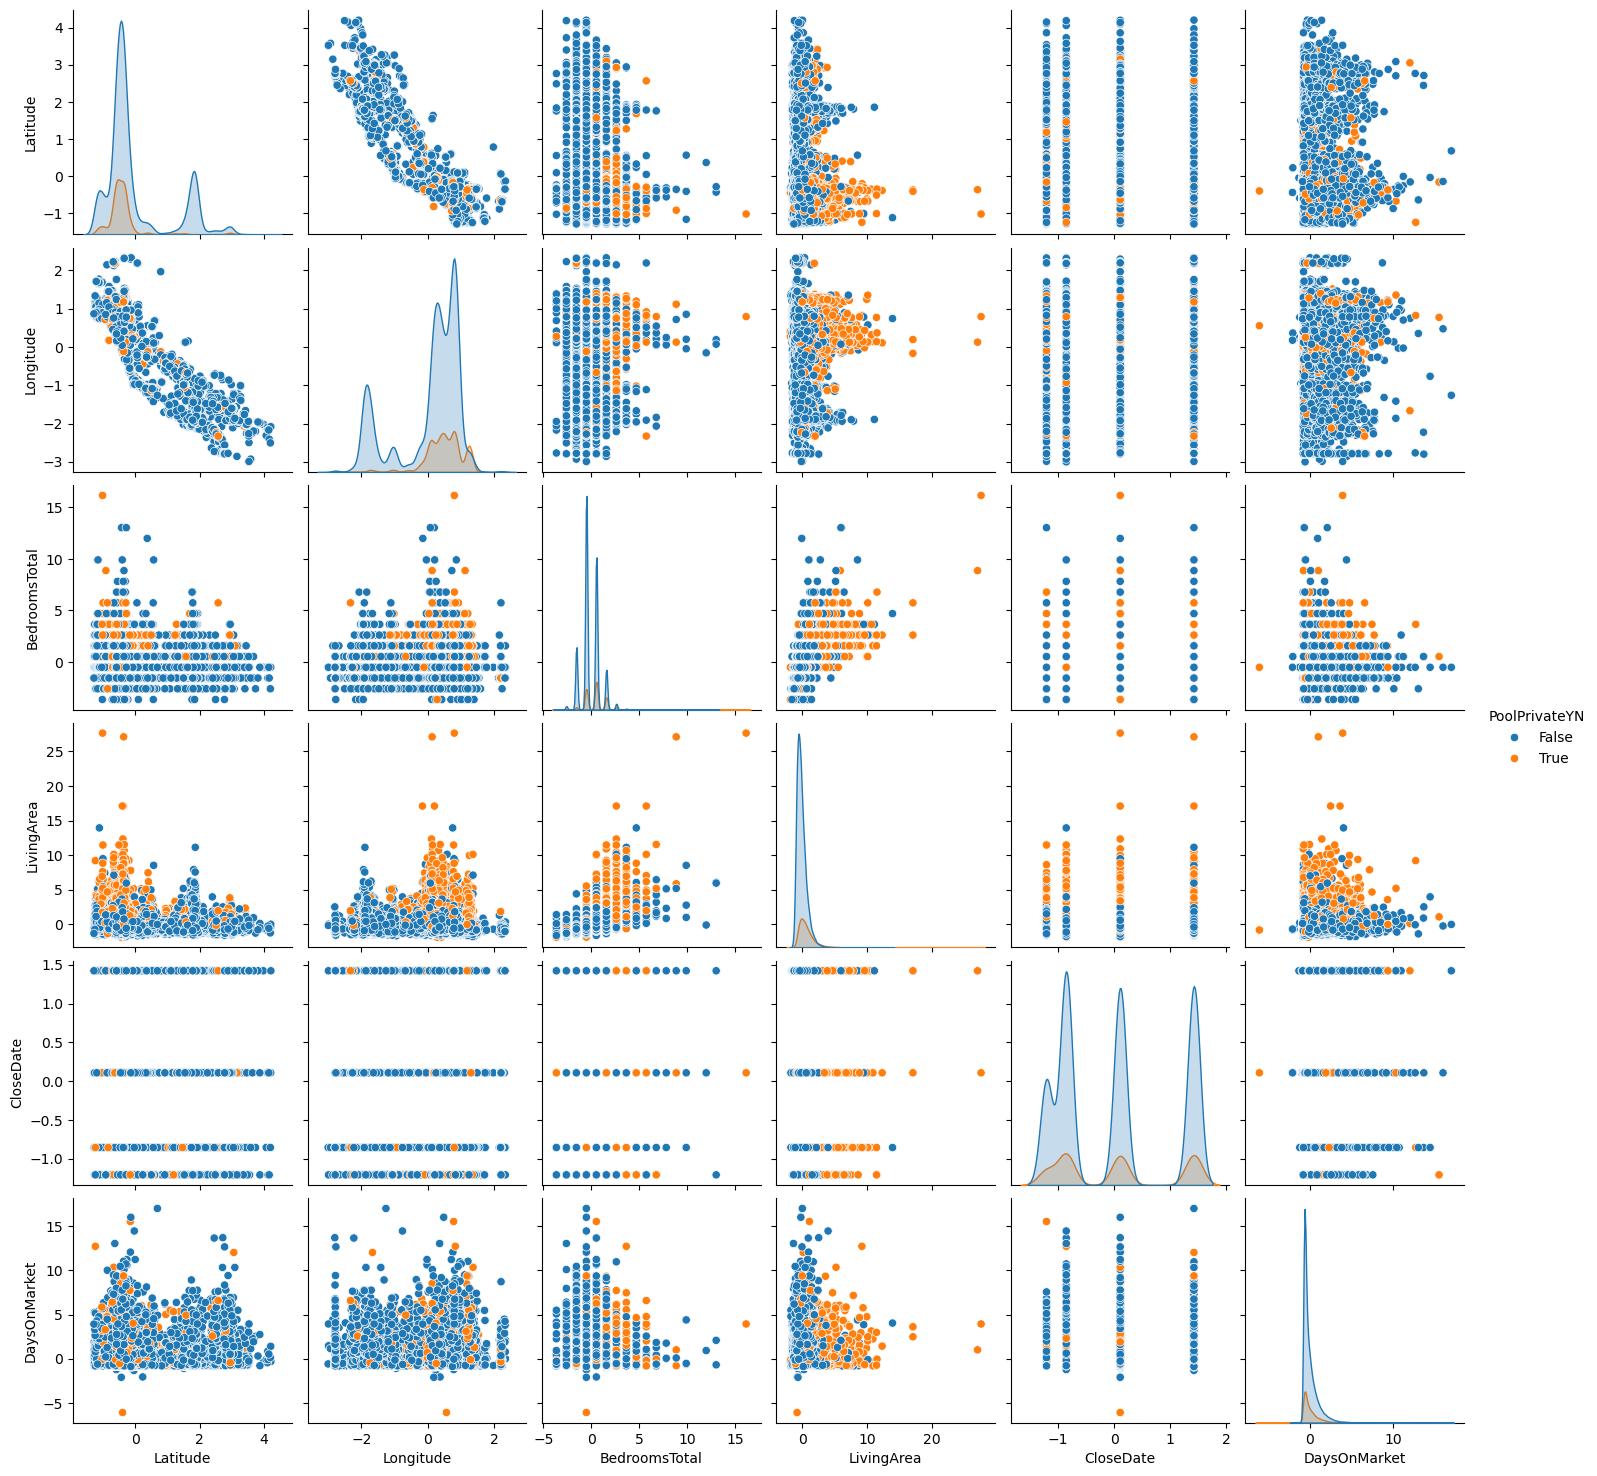

In [25]:
df_plot['PoolPrivateYN'] = df['PoolPrivateYN']
df_plot.dropna(inplace=True)
sns.pairplot(df_plot, vars=vars, hue='PoolPrivateYN')

# Verdict:

Clustering method seems to struggle here because none of the above features (FireplaceYN and PrivatePoolYN) are explainable.

## Solution:

We can try Random Forest as an imputer since it worked well on the processed data

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, cross_validate

y = df_plot['FireplaceYN']
df_plot.drop('FireplaceYN', axis=1, inplace=True)

# X_train, X_test, y_train, y_test = train_test_split(df_base, y, test_size=0.2, random_state=42)


KeyError: 'FireplaceYN'

In [40]:
model = RandomForestClassifier(n_estimators=100)

cv = cross_validate(model, df_plot, y, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])

cv

{'fit_time': array([7.11564589, 7.044554  , 6.90433502, 6.96371675, 6.98519707]),
 'score_time': array([0.20808125, 0.21826577, 0.20774603, 0.21404004, 0.20921183]),
 'test_accuracy': array([0.79426323, 0.79875611, 0.79780415, 0.79685219, 0.7950752 ]),
 'test_precision': array([0.81417275, 0.81781438, 0.82258065, 0.8148457 , 0.8217868 ]),
 'test_recall': array([0.93064488, 0.93203546, 0.92195376, 0.93403442, 0.91856423]),
 'test_f1': array([0.86852137, 0.87119704, 0.86943693, 0.87037862, 0.86748471])}

## Verdict:

Random Forest with n_estimators = 100 capture the information really well and can guarantee consistent result

## Modulize

In [64]:
import numpy as np
def random_forest_imputer(df: pd.DataFrame, vars:list, y:str, type='classifier'):
    vars.append(y)
    df_train = df[vars]
    df_train = df_train[df_train[y].notna()].copy()

    vars.remove(y)
    target = df_train[y].values
    train = df_train[vars].values
    if type == 'classifier':
        model = RandomForestClassifier(n_estimators=100)
        model.fit(train, target)
        prediction = model.predict(df[vars])
    else:
        model = RandomForestRegressor(n_estimators=100)
        model.fit(train, target)
        prediction = model.predict(df[vars])

    result = []
    for i in range(df.shape[0]):
        if pd.isna(df[y].iloc[i]):
            result.append(prediction[i])
        else:
            result.append(df[y].iloc[i])

    return pd.Series(result)

vars = ['Latitude',
 'Longitude',
 'BedroomsTotal',
 'LivingArea',
 'DaysOnMarket']

random_forest_imputer(df, vars, 'NewConstructionYN', type='classifier')

/Users/eddie/miniconda3/envs/houseML/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


0         True
1        False
2        False
3        False
4        False
         ...  
78840    False
78841    False
78842    False
78843    False
78844    False
Length: 78845, dtype: object

In [55]:
vars = ['Latitude',
 'Longitude',
 'BedroomsTotal',
 'LivingArea',
 'DaysOnMarket']

random_forest_imputer(df, vars, 'NewConstructionYN', type='classifier')

KeyboardInterrupt: 

In [ ]:
import duckdb

